In [1]:
import sys
sys.argv = ['']

# Graph-level Task

In [14]:
import torch
import argparse
from torch_geometric.datasets import WikipediaNetwork, TUDataset, Planetoid, Coauthor, CitationFull, QM9
from utils import load_graph_data, coarsening_classification, coarsening_regression, colater 
from torch.utils.data import DataLoader as T_DataLoader
from network import Classify_graph_gs, Regress_graph_gs
from time import time
import numpy as np

import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_max_pool

class Classify_graph(torch.nn.Module):
    def __init__(self, num_layer, num_feature, num_hidden, num_classes):
        super(Classify_graph, self).__init__()
        self.num_layers = num_layer
        self.conv = torch.nn.ModuleList()
        self.conv.append(GCNConv(num_feature, num_hidden))
        for i in range(self.num_layers - 1):
            self.conv.append(GCNConv(num_hidden, num_hidden))
        self.lt1 = torch.nn.Linear(num_hidden, num_classes)

    def reset_parameters(self):
        for module in self.conv:
            module.reset_parameters()
        self.lt1.reset_parameters()

    def forward(self, gc):
        x, edge_index, batch = gc.x, gc.edge_index, gc.batch
        for i in range(self.num_layers):
            x = self.conv[i](x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, training=self.training)
        x = global_max_pool(x, batch)
        x = self.lt1(x)
        return F.softmax(x, dim=1)

class Regress_graph(torch.nn.Module):
    def __init__(self, num_layer, num_feature, num_hidden):
        super(Regress_graph, self).__init__()
        self.num_layers = num_layer
        self.conv = torch.nn.ModuleList()
        self.conv.append(GCNConv(num_feature, num_hidden))
        for i in range(self.num_layers - 1):
            self.conv.append(GCNConv(num_hidden, num_hidden))
        self.lt1 = torch.nn.Linear(num_hidden, 1)

    def reset_parameters(self):
        for module in self.conv:
            module.reset_parameters()
        self.lt1.reset_parameters()

    def forward(self, gc):
        x, edge_index, batch = gc.x, gc.edge_index, gc.batch
        for i in range(self.num_layers):
            x = self.conv[i](x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, training=self.training)
        x = global_max_pool(x, batch)
        x = self.lt1(x)
        return x

def arg_correction(args):
    if args.super_graph:    
        args.cluster_node = False
        args.extra_node = False
    elif args.cluster_node:
        args.extra_node = False
        args.super_graph = False
    elif args.extra_node:
        args.cluster_node = False
        args.super_graph = False
    return args

def process_dataset(args):
    # Node Classification
    if args.dataset == 'dblp':
        dataset = CitationFull(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'Physics':
        dataset = Coauthor(root='./dataset/Physics', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'cora':
        dataset = Planetoid(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'citeseer':
        dataset = Planetoid(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'pubmed':
        dataset = Planetoid(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    #Node Regression
    elif args.dataset == 'chameleon':
        dataset = WikipediaNetwork(root='./dataset', name=args.dataset, geom_gcn_preprocess=False)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_reg'
    elif args.dataset == 'squirrel':
        dataset = WikipediaNetwork(root='./dataset', name=args.dataset, geom_gcn_preprocess=False)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_reg'
    elif args.dataset == 'crocodile':
        dataset = WikipediaNetwork(root='./dataset', name=args.dataset, geom_gcn_preprocess=False)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_reg'
    #Graph Classification
    elif args.dataset == 'ENZYMES':
        dataset = TUDataset(root='./dataset', name=args.dataset)
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_cls'
        args.num_classes = 6
    elif args.dataset == 'PROTEINS':
        dataset = TUDataset(root='./dataset', name=args.dataset)
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_cls'
    elif args.dataset == 'AIDS':
        dataset = TUDataset(root='./dataset', name=args.dataset)
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_cls'
        args.num_classes = 2
    #Graph Regression
    elif args.dataset == 'QM9':
        dataset = QM9(root='./dataset/QM9')
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_reg'
    return dataset, args

parser = argparse.ArgumentParser()
parser.add_argument('--dataset', type=str, default='chameleon')
parser.add_argument('--experiment', type=str, default='fixed') #'fixed', 'random', 'few'
parser.add_argument('--runs', type=int, default=20)
parser.add_argument('--exp_setup', type=str, default='Gc_train_2_Gs_infer') # 'Gc_train_2_Gs_infer', 'Gs_train_2_Gs_infer'
parser.add_argument('--hidden', type=int, default=512)
parser.add_argument('--epochs1', type=int, default=100)
parser.add_argument('--epochs2', type=int, default=300)
parser.add_argument('--num_layers1', type=int, default=2)
parser.add_argument('--num_layers2', type=int, default=2)
parser.add_argument('--batch_size', type=int, default=128)
parser.add_argument('--train_ratio', type=float, default=0.3)
parser.add_argument('--val_ratio', type=float, default=0.2)
parser.add_argument('--early_stopping', type=int, default=10)
parser.add_argument('--extra_node', type=bool, default=False)
parser.add_argument('--cluster_node', type=bool, default=False)
parser.add_argument('--super_graph', type=bool, default=False)
parser.add_argument('--lr', type=float, default=0.001)
parser.add_argument('--weight_decay', type=float, default=0.0005)
parser.add_argument('--normalize_features', type=bool, default=True)
parser.add_argument('--coarsening_ratio', type=float, default=0.5)
parser.add_argument('--coarsening_method', type=str, default='variation_neighborhoods') #'variation_neighborhoods', 'variation_edges', 'variation_cliques', 'heavy_edge', 'algebraic_JC', 'affinity_GS', 'kron'
parser.add_argument('--task', type = str, default = 'node_cls')         ### node_reg, graph_cls, graph_reg
parser.add_argument('--seed', type = int, default = None)               ### Seed for reproducibility
parser.add_argument('--property', type = int, default = 0)              ### Property for graph regression task
args = parser.parse_args()

args.dataset = "ENZYMES"                                                            ### Enter dataset name here      
args = arg_correction(args)
dataset, args = process_dataset(args)

index = 0                                                                           ### Index for single graph

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name_gs = "model.pt"                                                          ### Enter subgraph model name here
path_gs  = "./save/graph_cls/ENZYMES_Gc_train_2_Gs_infer_0.5_variation_neighborhoods_128_0.001/"   ### Add path here
model_name_b = "baseline_ENZYMES_batch_128_lr_0.001.pt"                                                           ### Enter baseline model name here
path_b  = "./final_models/"                                                                      ### Add path here

new_dataset = []
if args.task == "graph_cls":
    args.num_features, candidate, C_list, Gc_list, subgraph_list, component_2_subgraphs, CLIST, GcLIST = coarsening_classification(args, dataset[index], 1-args.coarsening_ratio, args.coarsening_method)
    Gc = load_graph_data(dataset[index], CLIST, GcLIST, candidate)
    Gs = subgraph_list
    new_dataset.append((dataset[index], Gc, Gs))

    colater_fn = colater()
    test_loader = T_DataLoader(new_dataset, batch_size=1, collate_fn=colater_fn)

    # Subgraph based model
    model_gs = Classify_graph_gs(args).to(device)
    loss_fn = torch.nn.CrossEntropyLoss().to(device)
    model_gs.load_state_dict(torch.load(path_gs + model_name_gs))
    model_gs.eval()
    for batch in test_loader:
        set_gs = batch[1]
        y = batch[2].to(device).type(torch.long)
        batch_tensor = batch[3].to(device)
        t1 = time()
        out_gs = model_gs(set_gs, batch_tensor).to(device)
        t2 = time()
        loss_gs = loss_fn(out_gs, y)

    # Baseline model
    model_b = Classify_graph(args.num_layers2, args.num_features, args.hidden, args.num_classes)
    loss_fn = torch.nn.CrossEntropyLoss().to(device)
    model_b.load_state_dict(torch.load(path_b + model_name_b))
    model_b.eval()
    for batch in test_loader:
        G = new_dataset[0][0]
        y = G.y.to(device).type(torch.long)
        t3 = time()
        out_b = model_b(G).to(device)
        t4 = time()
        loss_b = loss_fn(out_b, y)
    print(f"Subgraph-Based Model:\nGround Truth: {y.item()}\nPredicted: {out_gs.argmax().item()}\nOutput: {out_gs}\nLoss: {loss_gs.item()}\nTime: {t2-t1}s")
    print(f"\nBaseline Model:\nGround Truth: {y.item()}\nPredicted: {out_b.argmax().item()}\nOutput: {out_b}\nLoss: {loss_b.item()}\nTime: {t4-t3}s")

elif args.task == "graph_reg":

    args.num_features, candidate, C_list, Gc_list, subgraph_list, component_2_subgraphs, CLIST, GcLIST = coarsening_regression(args, dataset[index], 1-args.coarsening_ratio, args.coarsening_method)
    Gc = load_graph_data(dataset[index], CLIST, GcLIST, candidate)
    Gs = subgraph_list
    new_dataset.append((dataset[index], Gc, Gs))

    colater_fn = colater()
    test_loader = T_DataLoader(new_dataset, batch_size=1, collate_fn=colater_fn)

    # Subgraph based model
    model_gs = Regress_graph_gs(args).to(device)
    loss_fn = torch.nn.MSELoss().to(device)
    model_gs.load_state_dict(torch.load(path_gs + model_name_gs))
    model_gs.eval()
    for batch in test_loader:
        set_gs = batch[1]
        y = batch[2].to(device).type(torch.long)
        batch_tensor = batch[3].to(device)
        t1 = time()
        out_gs = model_gs(set_gs, batch_tensor).to(device)
        t2 = time()
        loss_gs = loss_fn(out_gs, y[:, args.property].view(-1, 1))
    
    # Baseline model
    model_b = Regress_graph(args.num_layers2, args.num_feature, args.hidden)
    loss_fn = torch.nn.MSELoss().to(device)
    model_b.load_state_dict(torch.load(path_b + model_name_b))
    model_b.eval()
    for batch in test_loader:
        G = new_dataset[0][0]
        y = G.y.to(device).type(torch.long)
        t3 = time()
        out_b = model_b(G).to(device)
        t4 = time()
        loss_b = loss_fn(out_b, y[:, args.property].view(-1, 1))
    print(f"Subgraph-Based Model:\nGround Truth: {y[:, args.property].item()}\nPredicted: {out_gs.item()}\nOutput: {out_gs}\nLoss: {loss_gs.item()}\nTime: {t2-t1}s")
    print(f"\nBaseline Model:\nGround Truth: {y[:, args.property].item()}\nPredicted: {out_b.item()}\nOutput: {out_b}\nLoss: {loss_b.item()}\nTime: {t4-t3}s")

/hdfs1/Data/weather/.venv/lib/python3.10/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


Subgraph-Based Model:
Ground Truth: 5
Predicted: 2
Output: tensor([[0.1894, 0.1751, 0.2234, 0.1410, 0.1457, 0.1254]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
Loss: 1.8335663080215454
Time: 0.16362714767456055

Baseline Model:
Ground Truth: 5
Predicted: 1
Output: tensor([[1.0398e-03, 5.0240e-01, 4.7976e-01, 1.3267e-02, 3.5177e-03, 1.5032e-05]],
       device='cuda:0', grad_fn=<ToCopyBackward0>)
Loss: 1.9859817028045654
Time: 0.4975001811981201


# Node-level Task (Node Classification)

In [225]:
import torch
import argparse
from torch_geometric.datasets import WikipediaNetwork, TUDataset, Planetoid, Coauthor, CitationFull, QM9
from utils import coarsening_classification, coarsening_regression, load_data_classification, load_data_regression
from torch_geometric.loader import DataLoader as G_DataLoader
from network import Classify_node, Regress_node
from time import time
import numpy as np

import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class Net1(torch.nn.Module):
    def __init__(self, num_features, hidden, num_layers, num_classes):
        super(Net1, self).__init__()
        self.num_layers = num_layers
        self.conv = torch.nn.ModuleList()
        self.conv.append(GCNConv(num_features, hidden))
        for i in range(self.num_layers - 1):
            self.conv.append(GCNConv(hidden, hidden))
        self.lt1 = torch.nn.Linear(hidden, num_classes)

    def reset_parameters(self):
        for module in self.conv:
            module.reset_parameters()
        self.lt1.reset_parameters()

    def forward(self, x, edge_index):
        for i in range(self.num_layers):
            x = self.conv[i](x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, training=self.training)
        x = self.lt1(x)
        return F.log_softmax(x, dim = 1)

class Net2(torch.nn.Module):
    def __init__(self, num_features, hidden, num_layers):
        super(Net2, self).__init__()
        self.num_layers = num_layers
        self.conv = torch.nn.ModuleList()
        self.conv.append(GCNConv(num_features, hidden))
        for i in range(self.num_layers - 1):
            self.conv.append(GCNConv(hidden, hidden))
        self.lt1 = torch.nn.Linear(hidden, 1)

    def reset_parameters(self):
        for module in self.conv:
            module.reset_parameters()
        self.lt1.reset_parameters()

    def forward(self, x, edge_index):
        for i in range(self.num_layers):
            x = self.conv[i](x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, training=self.training)
        x = self.lt1(x)
        return x


def arg_correction(args):
    if args.super_graph:    
        args.cluster_node = False
        args.extra_node = False
    elif args.cluster_node:
        args.extra_node = False
        args.super_graph = False
    elif args.extra_node:
        args.cluster_node = False
        args.super_graph = False
    return args

def process_dataset(args):
    # Node Classification
    if args.dataset == 'dblp':
        dataset = CitationFull(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'Physics':
        dataset = Coauthor(root='./dataset/Physics', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'cora':
        dataset = Planetoid(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'citeseer':
        dataset = Planetoid(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'pubmed':
        dataset = Planetoid(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    #Node Regression
    elif args.dataset == 'chameleon':
        dataset = WikipediaNetwork(root='./dataset', name=args.dataset, geom_gcn_preprocess=False)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_reg'
    elif args.dataset == 'squirrel':
        dataset = WikipediaNetwork(root='./dataset', name=args.dataset, geom_gcn_preprocess=False)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_reg'
    elif args.dataset == 'crocodile':
        dataset = WikipediaNetwork(root='./dataset', name=args.dataset, geom_gcn_preprocess=False)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_reg'
    #Graph Classification
    elif args.dataset == 'ENZYMES':
        dataset = TUDataset(root='./dataset', name=args.dataset)
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_cls'
        args.num_classes = 6
    elif args.dataset == 'PROTEINS':
        dataset = TUDataset(root='./dataset', name=args.dataset)
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_cls'
    elif args.dataset == 'AIDS':
        dataset = TUDataset(root='./dataset', name=args.dataset)
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_cls'
        args.num_classes = 2
    #Graph Regression
    elif args.dataset == 'QM9':
        dataset = QM9(root='./dataset/QM9')
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_reg'
    return dataset, args

parser = argparse.ArgumentParser()
parser.add_argument('--dataset', type=str, default='cora')
parser.add_argument('--experiment', type=str, default='fixed') #'fixed', 'random', 'few'
parser.add_argument('--runs', type=int, default=20)
parser.add_argument('--exp_setup', type=str, default='Gc_train_2_Gs_infer') # 'Gc_train_2_Gs_infer', 'Gs_train_2_Gs_infer'
parser.add_argument('--hidden', type=int, default=512)
parser.add_argument('--epochs1', type=int, default=100)
parser.add_argument('--epochs2', type=int, default=300)
parser.add_argument('--num_layers1', type=int, default=2)
parser.add_argument('--num_layers2', type=int, default=2)
parser.add_argument('--batch_size', type=int, default=128)
parser.add_argument('--train_ratio', type=float, default=0.3)
parser.add_argument('--val_ratio', type=float, default=0.2)
parser.add_argument('--early_stopping', type=int, default=10)
parser.add_argument('--extra_node', type=bool, default=True)
parser.add_argument('--cluster_node', type=bool, default=False)
parser.add_argument('--super_graph', type=bool, default=False)
parser.add_argument('--lr', type=float, default=0.01)
parser.add_argument('--weight_decay', type=float, default=0.0005)
parser.add_argument('--normalize_features', type=bool, default=True)
parser.add_argument('--coarsening_ratio', type=float, default=0.5)
parser.add_argument('--coarsening_method', type=str, default='variation_neighborhoods') #'variation_neighborhoods', 'variation_edges', 'variation_cliques', 'heavy_edge', 'algebraic_JC', 'affinity_GS', 'kron'
parser.add_argument('--task', type = str, default = 'node_cls')         ### node_reg, graph_cls, graph_reg
parser.add_argument('--seed', type = int, default = None)               ### Seed for reproducibility
parser.add_argument('--property', type = int, default = 0)              ### Property for graph regression task
args = parser.parse_args()

args.dataset = "cora"                                                               ### Enter dataset name here      
args = arg_correction(args)
dataset, args = process_dataset(args)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name_gs = "model.pt"                                                          ### Enter subgraph model name here
path_gs  = "./save/node_cls/final_testing/cora_fixed_Gc_train_2_Gs_infer_0.5_variation_neighborhoods_extra/"   ### Add path here
model_name_b = "baseline_cora_few.pt"                                                  ### Enter baseline model name here
path_b  = "./save/node_cls/baselines/"                                                                      ### Add path here

if args.task == "node_cls":
    args.num_features, candidate, C_list, Gc_list, subgraph_list, component_2_subgraphs, CLIST, GcLIST = coarsening_classification(args, dataset[0], 1-args.coarsening_ratio, args.coarsening_method)
    args.num_classes, coarsen_features, coarsen_train_labels, coarsen_train_mask, coarsen_val_labels, coarsen_val_mask, coarsen_edge, graphs = load_data_classification(args, dataset[0], candidate, C_list, Gc_list, args.experiment, subgraph_list)
    if args.normalize_features:
            coarsen_features = F.normalize(coarsen_features, p=1)
    
    indices = []
    num = 0
    for i in np.random.permutation(len(graphs)):
        if num != 20:
            if True in graphs[i].test_mask:
                if args.cluster_node:
                    index = np.random.choice(torch.cat([subgraph_list[i].orig_idx, torch.tensor(subgraph_list[i].actual_ext.flatten())], dim = 0)[graphs[i].test_mask], 1)[0]
                elif args.extra_node:
                    index = np.random.choice(subgraph_list[i].orig_idx[graphs[i].test_mask], 1)[0]
                j = subgraph_list[i].map_dict[index]
                indices.append((index, j, i))
                num += 1
        else:
            break
    # # Baseline model
    # model_b = Net1(dataset[0].x.shape[1], args.hidden, args.num_layers2, args.num_classes).to(device)
    # loss_fn = torch.nn.NLLLoss().to(device)
    # model_b.load_state_dict(torch.load(path_b + model_name_b))
    # model_b.eval()

    # x_ = dataset[0].x.to(device)
    # y_ = dataset[0].y.to(device)
    # edge_index_ = dataset[0].edge_index.to(device)
    # print(f"Baseline: {x_.shape}, {y_.shape}, {edge_index_.shape}")
    # t3 = time()
    # out_b = model_b(x_, edge_index_).to(device)
    # t4 = time()
    # loss_b = loss_fn(out_b[index], y_[index])

    # # Subgraph based model
    # model_gs = Net1(args.num_features, args.hidden, args.num_layers2, args.num_classes).to(device)
    # loss_fn = torch.nn.NLLLoss().to(device)
    # model_gs.load_state_dict(torch.load(path_gs + model_name_gs))
    # model_gs.eval()

    # x = graphs[i].x.to(device)
    # y = graphs[i].y.to(device)
    # edge_index = graphs[i].edge_index.to(device)
    # print(f"Subgraph: {x.shape}, {y.shape}, {edge_index.shape}")
    # t1 = time()
    # out_gs = model_gs(x, edge_index).to(device)
    # t2 = time()
    # loss_gs = loss_fn(out_gs[j], y[j])
    
    

    # print(f"Subgraph-Based Model:\nGround Truth: {y[j]}\nPredicted: {out_gs[j].argmax(dim = 0)}\nOutput: {out_gs[j]}\nLoss: {loss_gs.item()}\nTime: {t2-t1}s")
    # print(f"\nBaseline Model:\nGround Truth: {y_[index]}\nPredicted: {out_b[index].argmax(dim = 0)}\nOutput: {out_b[index]}\nLoss: {loss_b.item()}\nTime: {t4-t3}s")

# elif args.task == "node_reg":
#     args.num_features, candidate, C_list, Gc_list, subgraph_list, component_2_subgraphs, CLIST, GcLIST = coarsening_regression(args, dataset[0], 1-args.coarsening_ratio, args.coarsening_method)
#     graphs = load_data_regression(args, dataset[0], candidate, C_list, Gc_list, args.experiment, subgraph_list)
#     for j, subgraph in enumerate(subgraph_list):
#         if index in subgraph.orig_idx:
#             i = subgraph.map_dict[index]
#             break
#     graph_data = G_DataLoader([graphs[j]], batch_size=1)

#     # Subgraph based model
#     model_gs = Regress_node(args).to(device)
#     loss_fn = torch.nn.L1Loss().to(device)
#     model_gs.load_state_dict(torch.load(path_gs + model_name_gs))
#     model_gs.eval()
#     for graph in graph_data:
#         x = graph.x.to(device)
#         y = graph.y.to(device)
#         edge_index = graph.edge_index.to(device)
#         if True in graph.test_mask:
#             t1 = time()
#             out_gs = model_gs(x, edge_index).to(device)
#             t2 = time()
#             test_mask = graph.test_mask.to(device)
#             loss_gs = loss_fn(out_gs[test_mask], y[test_mask])
#         else:
#             print("No test nodes")
    
#     # Baseline model
#     model_b = Regress_node(args.num_features, args.hidden, args.num_layers2).to(device)
#     loss_fn = torch.nn.L1Loss().to(device)
#     model_b.load_state_dict(torch.load(path_b + model_name_b))
#     model_b.eval()
#     graph_data = G_DataLoader(dataset, batch_size=1)
#     for graph in graph_data:
#         x = graph.x.to(device)
#         y = graph.y.to(device)
#         edge_index = graph.edge_index.to(device)
#         if True in graph.test_mask:
#             t3 = time()
#             out_b = model_b(x, edge_index).to(device)
#             t4 = time()
#             test_mask = graph.test_mask.to(device)
#             loss_b = loss_fn(out_b[test_mask], y[test_mask])
#         else:
#             print("No test nodes")
#     print(f"Subgraph-Based Model:\nGround Truth: {y[test_mask]}\nPredicted: {out_gs[test_mask]}\nOutput: {out_gs}\nLoss: {loss_gs.item()}\nTime: {t2-t1}s")
#     print(f"\nBaseline Model:\nGround Truth: {y[test_mask]}\nPredicted: {out_b[test_mask]}\nOutput: {out_b}\nLoss: {loss_b.item()}\nTime: {t4-t3}s")

/hdfs1/Data/weather/CoarseGNN_Hrriday/CoPart-GNN/graph_coarsening/coarsening_utils.py:83: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  lk, Uk = sp.sparse.linalg.eigsh(T.toarray(), k=K, which="LM", tol=1e-5)


In [226]:
# Baseline model
model_b = Net1(dataset[0].x.shape[1], args.hidden, args.num_layers2, args.num_classes).to(device)
loss_fn = torch.nn.NLLLoss().to(device)
model_b.load_state_dict(torch.load(path_b + model_name_b))
model_b.eval()

total_time = 0
losses_b = []
times_b = []
all_label = []
all_out = []
for i in range(num):
    x_ = dataset[0].x.to(device)
    y_ = dataset[0].y.to(device)
    edge_index_ = dataset[0].edge_index.to(device)
    print(f"Baseline: {x_.shape}, {y_.shape}, {edge_index_.shape}")
    t3 = time()
    out_b = model_b(x_, edge_index_).to(device)
    t4 = time()
    total_time += t4 - t3
    loss_b = loss_fn(out_b[indices[i][0]], y_[indices[i][0]])
    all_label.append(y_[indices[i][0]].item())
    all_out.append(out_b[indices[i][0]].argmax().item())
    losses_b.append(loss_b.item())
    times_b.append(t4 - t3)
    print(f"\nBaseline Model:\nGround Truth: {y_[indices[i][0]]}\nPredicted: {out_b[indices[i][0]].argmax().item()}\nOutput: {out_b[indices[i][0]]}\nLoss: {loss_b.item()}\nTime: {t4 - t3}s\n")

Baseline: torch.Size([2708, 1433]), torch.Size([2708]), torch.Size([2, 10556])

Baseline Model:
Ground Truth: 5
Predicted: 6
Output: tensor([-4.5439, -6.7104, -5.3611, -2.4566, -5.0355, -2.6690, -0.1961],
       device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 2.6690118312835693
Time: 0.003712177276611328s

Baseline: torch.Size([2708, 1433]), torch.Size([2708]), torch.Size([2, 10556])

Baseline Model:
Ground Truth: 3
Predicted: 3
Output: tensor([-6.1901, -5.6099, -4.6276, -0.0229, -5.0667, -8.9632, -7.2825],
       device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 0.022867312654852867
Time: 0.0023956298828125s

Baseline: torch.Size([2708, 1433]), torch.Size([2708]), torch.Size([2, 10556])

Baseline Model:
Ground Truth: 3
Predicted: 4
Output: tensor([-1.9391, -2.7608, -5.3912, -1.8626, -0.4801, -5.9772, -4.4366],
       device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 1.8626456260681152
Time: 0.0038335323333740234s

Baseline: torch.Size([2708, 1433]), torch.Size([2708]), torch.Size([2

In [232]:
print(f"Average time (baseline): {total_time/num}\nAccuracy (baseline): {np.sum(np.array(all_label) == np.array(all_out))}/{num}")

Average time (baseline): 0.002372884750366211
Accuracy (baseline): 14/20


In [227]:
# Subgraph based model
model_gs = Net1(args.num_features, args.hidden, args.num_layers2, args.num_classes).to(device)
loss_fn = torch.nn.NLLLoss().to(device)
model_gs.load_state_dict(torch.load(path_gs + model_name_gs))
model_gs.eval()

total_time = 0
losses_gs = []
times_gs = []
all_label = []
all_out = []
for index, j, i in indices:
    x = graphs[i].x.to(device)
    y = graphs[i].y.to(device)
    edge_index = graphs[i].edge_index.to(device)
    print(f"Subgraph: {x.shape}, {y.shape}, {edge_index.shape}")
    t1 = time()
    out_gs = model_gs(x, edge_index).to(device)
    t2 = time()
    total_time += t2 - t1
    loss_gs = loss_fn(out_gs[j], y[j])
    all_label.append(y[j].item())
    all_out.append(out_gs[j].argmax().item())
    losses_gs.append(loss_gs.item())
    times_gs.append(t2 - t1)
    print(f"Subgraph-Based Model:\nGround Truth: {y[j]}\nPredicted: {out_gs[j].argmax().item()}\nOutput: {out_gs[j]}\nLoss: {loss_gs.item()}\nTime: {t2-t1}s\n")

Subgraph: torch.Size([2, 1433]), torch.Size([2]), torch.Size([2, 2])
Subgraph-Based Model:
Ground Truth: 5
Predicted: 5
Output: tensor([-76.4193, -65.2830, -46.7926, -69.1586, -60.4935,   0.0000, -34.9630],
       device='cuda:0', grad_fn=<SelectBackward0>)
Loss: -0.0
Time: 0.0030863285064697266s

Subgraph: torch.Size([2, 1433]), torch.Size([2]), torch.Size([2, 2])
Subgraph-Based Model:
Ground Truth: 3
Predicted: 3
Output: tensor([-52.2551, -61.0521, -49.7689,   0.0000, -27.4033, -89.5069, -89.9481],
       device='cuda:0', grad_fn=<SelectBackward0>)
Loss: -0.0
Time: 0.0023326873779296875s

Subgraph: torch.Size([3, 1433]), torch.Size([3]), torch.Size([2, 6])
Subgraph-Based Model:
Ground Truth: 3
Predicted: 3
Output: tensor([-1.1492e+01, -6.0911e+01, -6.1565e+01, -2.7061e-02, -3.6235e+00,
        -8.2201e+01, -7.7853e+01], device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 0.027060827240347862
Time: 0.00235748291015625s

Subgraph: torch.Size([25, 1433]), torch.Size([25]), torch.Size([2, 

In [228]:
print(f"Average time (subgraph): {total_time/num}\nAccuracy (subgraph): {np.sum(np.array(all_label) == np.array(all_out))}/{num}")

Average time (subgraph): 0.002372884750366211
Accuracy (subgraph): 14/20


In [ ]:
import matplotlib.pyplot as plt

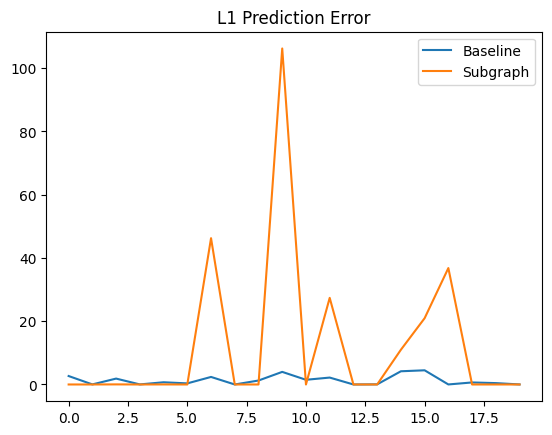

In [229]:
plt.title("L1 Prediction Error")
plt.plot(losses_b, label = "Baseline")
plt.plot(losses_gs, label = "Subgraph")
plt.legend()
plt.show()

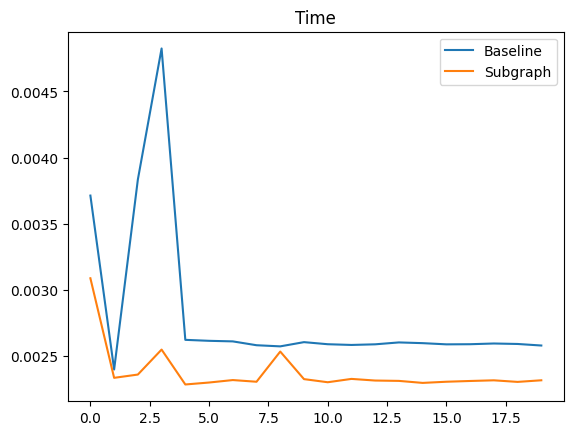

In [230]:
plt.title("Time")
plt.plot(times_b, label = "Baseline")
plt.plot(times_gs, label = "Subgraph")
plt.legend()
plt.show()

In [231]:
file_path = "final_results/node_cls.csv"
with open(file_path, 'a') as f:
    f.write(f"{args.dataset},False,{args.experiment},{args.exp_setup},{args.coarsening_method},{args.coarsening_ratio},{args.extra_node},{args.cluster_node},512,{num},{args.num_layers2},{args.batch_size},{args.lr},{np.mean(times_gs)},{np.mean(losses_gs)},{np.std(losses_gs)},{np.sum(np.array(all_label) == np.array(all_out))/num}\n")
f.close()

In [233]:
np.mean(times_b), np.mean(losses_b), np.std(losses_b), np.sum(np.array(all_label) == np.array(all_out))/num

(0.0028122305870056153, 1.3349448129025405, 1.4797378872332665, 0.7)

# Node-level Tasks (Node Regression)

In [132]:
import torch
import argparse
from torch_geometric.datasets import WikipediaNetwork, TUDataset, Planetoid, Coauthor, CitationFull, QM9
from utils import coarsening_classification, coarsening_regression, load_data_classification, load_data_regression
from torch_geometric.loader import DataLoader as G_DataLoader
from network import Classify_node, Regress_node
from time import time
import numpy as np

import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class Net1(torch.nn.Module):
    def __init__(self, num_features, hidden, num_layers, num_classes):
        super(Net1, self).__init__()
        self.num_layers = num_layers
        self.conv = torch.nn.ModuleList()
        self.conv.append(GCNConv(num_features, hidden))
        for i in range(self.num_layers - 1):
            self.conv.append(GCNConv(hidden, hidden))
        self.lt1 = torch.nn.Linear(hidden, num_classes)

    def reset_parameters(self):
        for module in self.conv:
            module.reset_parameters()
        self.lt1.reset_parameters()

    def forward(self, x, edge_index):
        for i in range(self.num_layers):
            x = self.conv[i](x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, training=self.training)
        x = self.lt1(x)
        return F.log_softmax(x, dim = 1)

class Net2(torch.nn.Module):
    def __init__(self, num_features, hidden, num_layers):
        super(Net2, self).__init__()
        self.num_layers = num_layers
        self.conv = torch.nn.ModuleList()
        self.conv.append(GCNConv(num_features, hidden))
        for i in range(self.num_layers - 1):
            self.conv.append(GCNConv(hidden, hidden))
        self.lt1 = torch.nn.Linear(hidden, 1)

    def reset_parameters(self):
        for module in self.conv:
            module.reset_parameters()
        self.lt1.reset_parameters()

    def forward(self, x, edge_index):
        for i in range(self.num_layers):
            x = self.conv[i](x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, training=self.training)
        x = self.lt1(x)
        return x


def arg_correction(args):
    if args.super_graph:    
        args.cluster_node = False
        args.extra_node = False
    elif args.cluster_node:
        args.extra_node = False
        args.super_graph = False
    elif args.extra_node:
        args.cluster_node = False
        args.super_graph = False
    return args

def process_dataset(args):
    # Node Classification
    if args.dataset == 'dblp':
        dataset = CitationFull(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'Physics':
        dataset = Coauthor(root='./dataset/Physics', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'cora':
        dataset = Planetoid(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'citeseer':
        dataset = Planetoid(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    elif args.dataset == 'pubmed':
        dataset = Planetoid(root='./dataset', name=args.dataset)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_cls'
    #Node Regression
    elif args.dataset == 'chameleon':
        dataset = WikipediaNetwork(root='./dataset', name=args.dataset, geom_gcn_preprocess=False)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_reg'
    elif args.dataset == 'squirrel':
        dataset = WikipediaNetwork(root='./dataset', name=args.dataset, geom_gcn_preprocess=False)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_reg'
    elif args.dataset == 'crocodile':
        dataset = WikipediaNetwork(root='./dataset', name=args.dataset, geom_gcn_preprocess=False)
        if args.normalize_features:
            dataset.x = torch.nn.functional.normalize(dataset.x, p=1)
        args.task = 'node_reg'
    #Graph Classification
    elif args.dataset == 'ENZYMES':
        dataset = TUDataset(root='./dataset', name=args.dataset)
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_cls'
        args.num_classes = 6
    elif args.dataset == 'PROTEINS':
        dataset = TUDataset(root='./dataset', name=args.dataset)
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_cls'
    elif args.dataset == 'AIDS':
        dataset = TUDataset(root='./dataset', name=args.dataset)
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_cls'
        args.num_classes = 2
    #Graph Regression
    elif args.dataset == 'QM9':
        dataset = QM9(root='./dataset/QM9')
        for i in range(len(dataset)):
            if args.normalize_features:
                dataset[i].x = torch.nn.functional.normalize(dataset[i].x, p=1)
        args.task = 'graph_reg'
    return dataset, args

parser = argparse.ArgumentParser()
parser.add_argument('--dataset', type=str, default='chameleon')
parser.add_argument('--experiment', type=str, default='fixed') #'fixed', 'random', 'few'
parser.add_argument('--runs', type=int, default=20)
parser.add_argument('--exp_setup', type=str, default='Gc_train_2_Gs_infer') # 'Gc_train_2_Gs_infer', 'Gs_train_2_Gs_infer'
parser.add_argument('--hidden', type=int, default=512)
parser.add_argument('--epochs1', type=int, default=100)
parser.add_argument('--epochs2', type=int, default=300)
parser.add_argument('--num_layers1', type=int, default=2)
parser.add_argument('--num_layers2', type=int, default=2)
parser.add_argument('--batch_size', type=int, default=128)
parser.add_argument('--train_ratio', type=float, default=0.3)
parser.add_argument('--val_ratio', type=float, default=0.2)
parser.add_argument('--early_stopping', type=int, default=10)
parser.add_argument('--extra_node', type=bool, default=False)
parser.add_argument('--cluster_node', type=bool, default=True)
parser.add_argument('--super_graph', type=bool, default=False)
parser.add_argument('--lr', type=float, default=0.01)
parser.add_argument('--weight_decay', type=float, default=0.0005)
parser.add_argument('--normalize_features', type=bool, default=True)
parser.add_argument('--coarsening_ratio', type=float, default=0.5)
parser.add_argument('--coarsening_method', type=str, default='variation_neighborhoods') #'variation_neighborhoods', 'variation_edges', 'variation_cliques', 'heavy_edge', 'algebraic_JC', 'affinity_GS', 'kron'
parser.add_argument('--task', type = str, default = 'node_cls')         ### node_reg, graph_cls, graph_reg
parser.add_argument('--seed', type = int, default = None)               ### Seed for reproducibility
parser.add_argument('--property', type = int, default = 0)              ### Property for graph regression task
args = parser.parse_args()

args.dataset = "crocodile"                                                               ### Enter dataset name here      
args = arg_correction(args)
dataset, args = process_dataset(args)

index = 0                                                                           ### Index for single node in graph

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name_gs = "model.pt"                                                          ### Enter subgraph model name here
path_gs  = "./save/node_reg/final_testing/crocodile_Gc_train_2_Gs_infer_05_variation_neighborhoods_cluster/"   ### Add path here
model_name_b = "baseline_crocodile.pt"                                                  ### Enter baseline model name here
path_b  = "./save/node_reg/baselines/"                                                                      ### Add path here

if args.task == "node_cls":
    pass
    # args.num_features, candidate, C_list, Gc_list, subgraph_list, component_2_subgraphs, CLIST, GcLIST = coarsening_classification(args, dataset[0], 1-args.coarsening_ratio, args.coarsening_method)
    # args.num_classes, coarsen_features, coarsen_train_labels, coarsen_train_mask, coarsen_val_labels, coarsen_val_mask, coarsen_edge, graphs = load_data_classification(args, dataset[0], candidate, C_list, Gc_list, args.experiment, subgraph_list)
    # if args.normalize_features:
    #         coarsen_features = F.normalize(coarsen_features, p=1)
    # for j, subgraph in enumerate(subgraph_list):
    #     if index in subgraph.orig_idx:
    #         i = subgraph.map_dict[index]
    #         break
    # graph_data = G_DataLoader([graphs[j]], batch_size=1)

    # # Subgraph based model
    # model_gs = Classify_node(args).to(device)
    # loss_fn = torch.nn.NLLLoss().to(device)
    # model_gs.load_state_dict(torch.load(path_gs + model_name_gs))
    # model_gs.eval()
    # for graph in graph_data:
    #     x = graph.x.to(device)
    #     y = graph.y.to(device)
    #     edge_index = graph.edge_index.to(device)
    #     if True in graph.test_mask:
    #         t1 = time()
    #         out_gs = model_gs(x, edge_index).to(device)
    #         t2 = time()
    #         test_mask = graph.test_mask.to(device)
    #         loss_gs = loss_fn(out_gs[test_mask], y[test_mask])
    #     else:
    #         print("No test nodes")
    
    # # Baseline model
    # model_b = Net1(dataset[0].x.shape[1], args.hidden, args.num_layers2, args.num_classes).to(device)
    # loss_fn = torch.nn.NLLLoss().to(device)
    # model_b.load_state_dict(torch.load(path_b + model_name_b))
    # model_b.eval()
    # graph_data = G_DataLoader(dataset, batch_size=1)
    # for graph in graph_data:
    #     x = graph.x.to(device)
    #     y = graph.y.to(device)
    #     edge_index = graph.edge_index.to(device)
    #     if True in graph.test_mask:
    #         t3 = time()
    #         out_b = model_b(x, edge_index).to(device)
    #         t4 = time()
    #         test_mask = graph.test_mask.to(device)
    #         loss_b = loss_fn(out_b[test_mask], y[test_mask])
    #     else:
    #         print("No test nodes")
    # print(f"Subgraph-Based Model:\nGround Truth: {y[test_mask]}\nPredicted: {out_gs[test_mask].argmax(dim = 1)}\nOutput: {out_gs[test_mask]}\nLoss: {loss_gs.item()}\nTime: {t2-t1}s")
    # print(f"\nBaseline Model:\nGround Truth: {y[test_mask]}\nPredicted: {out_b[test_mask].argmax(dim = 1)}\nOutput: {out_b[test_mask]}\nLoss: {loss_b.item()}\nTime: {t4-t3}s")

elif args.task == "node_reg":
    args.num_features, candidate, C_list, Gc_list, subgraph_list, component_2_subgraphs, CLIST, GcLIST = coarsening_regression(args, dataset[0], 1-args.coarsening_ratio, args.coarsening_method)
    graphs = load_data_regression(args, dataset[0], subgraph_list)

    indices = []
    num = 0
    for i in np.random.permutation(len(graphs)):
        if num != 20:
            if True in graphs[i].test_mask:
                if args.cluster_node:
                    index = np.random.choice(torch.cat([subgraph_list[i].orig_idx, torch.tensor(subgraph_list[i].actual_ext.flatten())], dim = 0)[graphs[i].test_mask], 1)[0]
                elif args.extra_node:
                    index = np.random.choice(subgraph_list[i].orig_idx[graphs[i].test_mask], 1)[0]
                j = subgraph_list[i].map_dict[index]
                indices.append((index, j, i))
                num += 1
        else:
            break
    
    # print(f"Test Node Index: {index}, Meta Node Index: {j}, Subgraph Index: {i}")

    # # Subgraph based model
    # model_gs = Regress_node(args).to(device)
    # loss_fn = torch.nn.L1Loss().to(device)
    # model_gs.load_state_dict(torch.load(path_gs + model_name_gs))
    # model_gs.eval()
    # for graph in graph_data:
    #     x = graph.x.to(device)
    #     y = graph.y.to(device)
    #     edge_index = graph.edge_index.to(device)
    #     if True in graph.test_mask:
    #         t1 = time()
    #         out_gs = model_gs(x, edge_index).to(device)
    #         t2 = time()
    #         test_mask = graph.test_mask.to(device)
    #         loss_gs = loss_fn(out_gs[test_mask], y[test_mask])
    #     else:
    #         print("No test nodes")
    
    # # Baseline model
    # model_b = Regress_node(args).to(device)
    # loss_fn = torch.nn.L1Loss().to(device)
    # model_b.load_state_dict(torch.load(path_b + model_name_b))
    # model_b.eval()
    # graph_data = G_DataLoader(dataset, batch_size=1)
    # for graph in graph_data:
    #     x = graph.x.to(device)
    #     y = graph.y.to(device)
    #     edge_index = graph.edge_index.to(device)
    #     if True in graph.test_mask:
    #         t3 = time()
    #         out_b = model_b(x, edge_index).to(device)
    #         t4 = time()
    #         test_mask = graph.test_mask.to(device)
    #         loss_b = loss_fn(out_b[test_mask], y[test_mask])
    #     else:
    #         print("No test nodes")
    # print(f"Subgraph-Based Model:\nGround Truth: {y[test_mask]}\nPredicted: {out_gs[test_mask]}\nOutput: {out_gs}\nLoss: {loss_gs.item()}\nTime: {t2-t1}s")
    # print(f"\nBaseline Model:\nGround Truth: {y[test_mask]}\nPredicted: {out_b[test_mask]}\nOutput: {out_b}\nLoss: {loss_b.item()}\nTime: {t4-t3}s")

2024-08-11 10:10:53,926:[WARNING](pygsp.graphs.graph.check_weights): The main diagonal of the weight matrix is not 0!
2024-08-11 10:10:55,760:[WARNING](pygsp.graphs.graph.check_weights): The main diagonal of the weight matrix is not 0!


In [133]:
# Baseline model
model_b = Regress_node(args).to(device)
loss_fn = torch.nn.L1Loss().to(device)
model_b.load_state_dict(torch.load(path_b + model_name_b))
model_b.eval()
losses_b = []
times_b = []
total_time = 0
for i in range(num):
    x_ = dataset[0].x.to(device)
    y_ = dataset[0].y.to(device)
    edge_index_ = dataset[0].edge_index.to(device)
    print(f"Baseline: {x_.shape}, {y_.shape}, {edge_index_.shape}")
    t3 = time()
    out_b = model_b(x_, edge_index_).to(device)
    t4 = time()
    total_time += t4 - t3
    loss_b = loss_fn(out_b[indices[i][0]][0], y_[indices[i][0]])
    losses_b.append(loss_b.item())
    times_b.append(t4 - t3)
    print(f"\nBaseline Model:\nGround Truth: {y_[indices[i][0]]}\nPredicted: {out_b[indices[i][0]]}\nLoss: {loss_b.item()}\nTime: {t4 - t3}s\n")

Baseline: torch.Size([11631, 128]), torch.Size([11631]), torch.Size([2, 341691])

Baseline Model:
Ground Truth: 5.973809719085693
Predicted: tensor([7.6801], device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 1.7063384056091309
Time: 0.009485721588134766s

Baseline: torch.Size([11631, 128]), torch.Size([11631]), torch.Size([2, 341691])

Baseline Model:
Ground Truth: 6.629363059997559
Predicted: tensor([5.0250], device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 1.6043963432312012
Time: 0.008029699325561523s

Baseline: torch.Size([11631, 128]), torch.Size([11631]), torch.Size([2, 341691])

Baseline Model:
Ground Truth: 3.8066625595092773
Predicted: tensor([6.8091], device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 3.00242280960083
Time: 0.007995843887329102s

Baseline: torch.Size([11631, 128]), torch.Size([11631]), torch.Size([2, 341691])

Baseline Model:
Ground Truth: 6.593044757843018
Predicted: tensor([9.0284], device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 2.435398578643799
Time: 0

In [134]:
print(f"Average time (baseline): {total_time/num}")

Average time (baseline): 0.007062113285064698


In [135]:
# Subgraph based model
model_gs = Regress_node(args).to(device)
loss_fn = torch.nn.L1Loss().to(device)
model_gs.load_state_dict(torch.load(path_gs + model_name_gs))
model_gs.eval()

total_time = 0
losses_gs = []
times_gs = []
for index, j, i in indices:
    x = graphs[i].x.to(device)
    y = graphs[i].y.to(device)
    edge_index = graphs[i].edge_index.to(device)
    print(f"Subgraph: {x.shape}, {y.shape}, {edge_index.shape}")
    t1 = time()
    out_gs = model_gs(x, edge_index).to(device)
    t2 = time()
    total_time += t2 - t1
    loss_gs = loss_fn(out_gs[j][0], y[j])
    losses_gs.append(loss_gs.item())
    times_gs.append(t2 - t1)
    print(f"Subgraph-Based Model:\nGround Truth: {y[j]}\nPredicted: {out_gs[j]}\nLoss: {loss_gs.item()}\nTime: {t2-t1}s\n")

Subgraph: torch.Size([5, 128]), torch.Size([5]), torch.Size([2, 12])
Subgraph-Based Model:
Ground Truth: 5.973809719085693
Predicted: tensor([6.9099], device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 0.9361362457275391
Time: 0.002698183059692383s

Subgraph: torch.Size([2, 128]), torch.Size([2]), torch.Size([2, 2])
Subgraph-Based Model:
Ground Truth: 6.629363059997559
Predicted: tensor([6.6403], device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 0.010955333709716797
Time: 0.0019106864929199219s

Subgraph: torch.Size([4, 128]), torch.Size([4]), torch.Size([2, 12])
Subgraph-Based Model:
Ground Truth: 3.8066625595092773
Predicted: tensor([5.6729], device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 1.8662714958190918
Time: 0.0018777847290039062s

Subgraph: torch.Size([45, 128]), torch.Size([45]), torch.Size([2, 1386])
Subgraph-Based Model:
Ground Truth: 6.593044757843018
Predicted: tensor([8.3141], device='cuda:0', grad_fn=<SelectBackward0>)
Loss: 1.721092700958252
Time: 0.002074480056762695

In [136]:
print(f"Average time (subgraph): {total_time/num}")

Average time (subgraph): 0.00192108154296875


In [129]:
import matplotlib.pyplot as plt

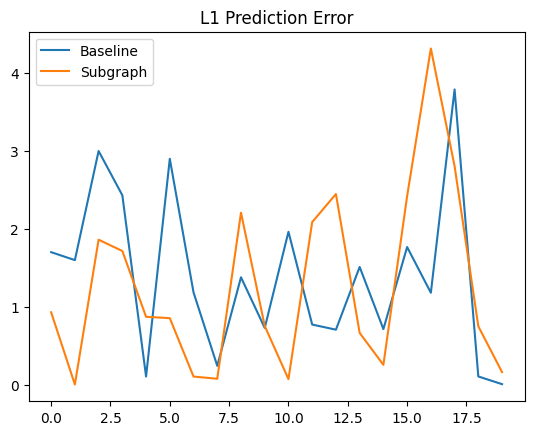

In [137]:
plt.title("L1 Prediction Error")
plt.plot(losses_b, label = "Baseline")
plt.plot(losses_gs, label = "Subgraph")
plt.legend()
plt.show()

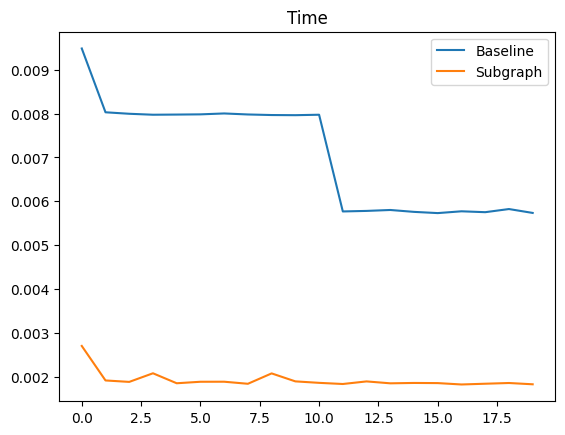

In [138]:
plt.title("Time")
plt.plot(times_b, label = "Baseline")
plt.plot(times_gs, label = "Subgraph")
plt.legend()
plt.show()

In [139]:
file_path = "final_results/node_reg.csv"
with open(file_path, 'a') as f:
    f.write(f"{args.dataset},False,{args.coarsening_method},{args.coarsening_ratio},{args.extra_node},{args.cluster_node},512,{num},{args.num_layers2},{args.batch_size},{args.lr},{np.mean(times_gs)},{np.mean(losses_gs)},{np.std(losses_gs)}\n")
f.close()

In [140]:
np.mean(times_b), np.mean(losses_b), np.std(losses_b)

(0.007062113285064698, 1.3949599146842957, 1.015614095401038)